#  Case Study

Greening the Fleet – Data-Driven Sustainability at EcoTrans Logistics
Background

EcoTrans Logistics is a mid-sized European transport company operating a fleet of delivery trucks across urban and regional routes. Facing rising fuel costs, stricter environmental regulations, and customer demand for greener logistics, the company has launched a data-driven initiative to reduce its carbon footprint.
You are part of the data analytics team tasked with analyzing operational data and identifying opportunities to improve sustainability while maintaining efficiency.
The following tasks correspond to different stages of your Jupyter Notebook analysis.

![The typical workflow](graph.png)

# 1. Data Loading & Initial Exploration


(Related to code blocks: importing libraries, loading datasets, displaying head/info)

EcoTrans has provided datasets containing:
Shipping and Aircraft data (fuel type, age, capacity, CO2 output)

Your Tasks:

1. Load the datasets and inspect their structure.
2. Identify key variables relevant to sustainability (e.g. what could be relevant for further investigation).
3. Check for inconsistencies in data types (e.g., numeric vs. categorical).
4. Provide an initial summary of the dataset:
-   Size of the dataset
-   Number of variables
-   columns/variables we might drop (null columns)

In [235]:
# packages loading
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


In [236]:
# Loading the data in 

aviation_data=pd.read_csv("international-aviation_emissions_sources_v5_5_0.csv")
shipping_data=pd.read_csv("international-shipping_emissions_sources_v5_5_0.csv")


In [237]:
aviation_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 135420 entries, 0 to 135419
Data columns (total 47 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   source_id               135420 non-null  int64  
 1   source_name             135420 non-null  str    
 2   source_type             135420 non-null  str    
 3   iso3_country            135420 non-null  str    
 4   sector                  135420 non-null  str    
 5   subsector               135420 non-null  str    
 6   start_time              135420 non-null  str    
 7   end_time                135420 non-null  str    
 8   lat                     135420 non-null  float64
 9   lon                     135420 non-null  float64
 10  geometry_ref            0 non-null       float64
 11  gas                     135420 non-null  str    
 12  emissions_quantity      135420 non-null  float64
 13  temporal_granularity    135420 non-null  str    
 14  activity                135420 

In [238]:
aviation_data.describe()

,source_id,lat,lon,geometry_ref,emissions_quantity,activity,emissions_factor,capacity,capacity_factor,other1,other1_def,other2,other2_def,other3,other3_def,other4,other4_def,other5,other5_def,other6,other6_def,other7,other7_def,other8,other8_def,other9,other9_def,other10,other10_def,sector_id,lat_lon
count,1.354200e+05,135420.000000,135420.000000,0.0,1.354200e+05,135420.000000,1.354200e+05,135420.000000,135420.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135420.0,0.0
mean,4.781811e+06,27.805174,10.273544,NaN,1.777794e+04,5582.035904,3.184848e+00,794.238621,2.640764,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.0,NaN
std,8.046154e+06,23.933280,75.547543,NaN,8.809461e+04,27660.538505,1.017911e-14,2833.385969,4.662863,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
min,8.268740e+05,-54.843300,-179.667007,NaN,0.000000e+00,0.000000,3.184848e+00,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.0,NaN
25%,3.166576e+06,13.898300,-61.427159,NaN,0.000000e+00,0.000000,3.184848e+00,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.0,NaN
50%,3.167826e+06,34.053749,14.687551,NaN,5.674604e+01,17.817505,3.184848e+00,10.000000,0.938763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.0,NaN
75%,3.169110e+06,44.883974,55.675500,NaN,2.638393e+03,828.420547,3.184848e+00,259.000000,3.535523,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.0,NaN
max,5.112815e+07,78.246101,179.195999,NaN,1.868720e+06,586753.356177,3.184848e+00,43471.000000,78.992528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.0,NaN


# 2.  Data Cleaning & Preparation


Before analysis, the dataset must be cleaned.

Tasks:
1. Identify missing or null values across all columns and drop the columns.
2. Decide how to handle missing data:
    - Remove rows?
    - Impute values?
3. Convert the "end_time" variable from a string to a datatime format (try to do this with a function which would work in general for any csv containing that column)
4. Build a function which adds a new column for the year from the respective end_time variable. It will help us to show trend development later on. Also make sure, it is converted into a numeric format.


In [239]:
# cleaning the null columns

aviation_data=aviation_data.dropna(axis=1)
shipping_data=shipping_data.dropna(axis=1)


In [240]:
# converting a dataformat
csv_list=[aviation_data,shipping_data]
def data_conversion(data):
    data["end_time"]=pd.to_datetime(data["end_time"])
    return data

for data in csv_list:
    data_conversion(data)

In [241]:
aviation_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 135420 entries, 0 to 135419
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   source_id               135420 non-null  int64         
 1   source_name             135420 non-null  str           
 2   source_type             135420 non-null  str           
 3   iso3_country            135420 non-null  str           
 4   sector                  135420 non-null  str           
 5   subsector               135420 non-null  str           
 6   start_time              135420 non-null  str           
 7   end_time                135420 non-null  datetime64[us]
 8   lat                     135420 non-null  float64       
 9   lon                     135420 non-null  float64       
 10  gas                     135420 non-null  str           
 11  emissions_quantity      135420 non-null  float64       
 12  temporal_granularity    135420 non-null  

In [242]:
# function for building a new column year

def year(data):
    data["year"]=pd.to_numeric(data["end_time"].dt.year)
    return data

for data in csv_list:
    year(data)

Your data are now in a format with which we can start doing the real analysis. 
As we are primarily interested in identying patterns which help as to maintain and improve our operations in regards to sustainability topics, it might make sense to get a feeling on the emissions data 
E.g. start to plot the emissions data (emissions_quantity) of the aircraft fleet on a histogramm to get a feeling for the dimensions.

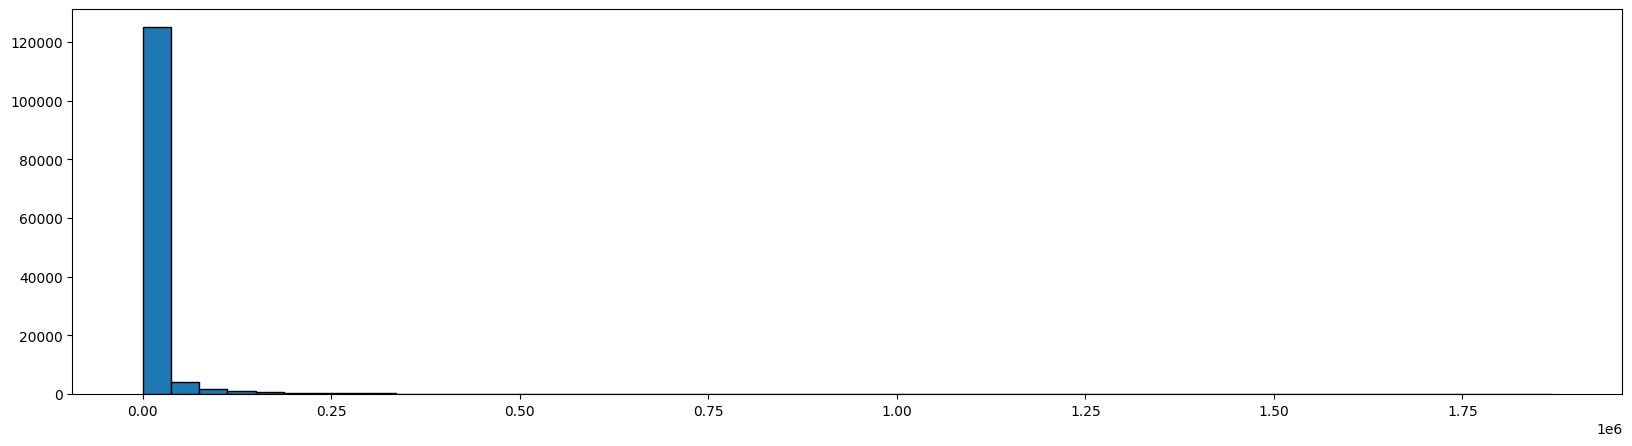

In [243]:
plt.figure(figsize=(20,5))
plt.hist(aviation_data["emissions_quantity"],edgecolor="black",bins=50)
plt.show()

Does it make sense to plot these values without some further manipulation? Would you hand over this histogramm you your boss? Any idea to convert your emissions data into a more handy format?
It might be useful to convert the data with the logarithm. Define a function for both files which performs a log-transformation on these columns

Your Task:
- Build a function which performs a log-transformation the emissions_quantity data 
- validate that your function worked (.describe() is a fast way to get some stats)
- plot the data again, can you spot a problem? 
- read the error code and report what the problem might be 
- try to find a way to solve the problem 

In [244]:
def logarithmic(data):
    data["emissions_quantity"]=np.log2(data["emissions_quantity"])
    return data

for data in csv_list:
    logarithmic(data)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [245]:
aviation_data.describe()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,source_id,end_time,lat,lon,emissions_quantity,activity,emissions_factor,capacity,capacity_factor,sector_id,year
count,1.354200e+05,135420,135420.000000,135420.000000,1.354200e+05,135420.000000,1.354200e+05,135420.000000,135420.000000,135420.0,135420.000000
mean,4.781811e+06,2023-07-31 12:59:00.983606,27.805174,10.273544,-inf,5582.035904,3.184848e+00,794.238621,2.640764,64.0,2023.049180
min,8.268740e+05,2021-01-31 00:00:00,-54.843300,-179.667007,-inf,0.000000,3.184848e+00,0.000000,0.000000,64.0,2021.000000
25%,3.166576e+06,2022-04-30 00:00:00,13.898300,-61.427159,NaN,0.000000,3.184848e+00,0.000000,0.000000,64.0,2022.000000
50%,3.167826e+06,2023-07-31 00:00:00,34.053749,14.687551,5.826448e+00,17.817505,3.184848e+00,10.000000,0.938763,64.0,2023.000000
75%,3.169110e+06,2024-10-31 00:00:00,44.883974,55.675500,1.136544e+01,828.420547,3.184848e+00,259.000000,3.535523,64.0,2024.000000
max,5.112815e+07,2026-01-31 00:00:00,78.246101,179.195999,2.083362e+01,586753.356177,3.184848e+00,43471.000000,78.992528,64.0,2026.000000
std,8.046154e+06,NaN,23.933280,75.547543,NaN,27660.538505,1.017911e-14,2833.385969,4.662863,0.0,1.453393


In [246]:
#plt.figure(figsize=(20,5))
#plt.hist(aviation_data["emissions_quantity"],edgecolor="black",bins=50)
#plt.show()

The log-transformation lead to negative infinite data entries. As it does not make any sense to record negative values, we now want to impute any negative values with exact 0. 

Your Task:
- again write a function which returns the datasets just with 0 or positive emissions_quantity data


In [247]:
def zero_cleaning(data):
    data["emissions_quantity"]=data["emissions_quantity"].replace(-np.inf,0)
    data.loc[data["emissions_quantity"]<0,"emissions_quantity"]=0
    return data

for data in csv_list:
    zero_cleaning(data)

Verify if your function worked by calling .describe() again. Then again, plot your data! It should look nice and smooth now..

In [248]:
aviation_data.describe()

,source_id,end_time,lat,lon,emissions_quantity,activity,emissions_factor,capacity,capacity_factor,sector_id,year
count,1.354200e+05,135420,135420.000000,135420.000000,135420.000000,135420.000000,1.354200e+05,135420.000000,135420.000000,135420.0,135420.000000
mean,4.781811e+06,2023-07-31 12:59:00.983606,27.805174,10.273544,6.011671,5582.035904,3.184848e+00,794.238621,2.640764,64.0,2023.049180
min,8.268740e+05,2021-01-31 00:00:00,-54.843300,-179.667007,0.000000,0.000000,3.184848e+00,0.000000,0.000000,64.0,2021.000000
25%,3.166576e+06,2022-04-30 00:00:00,13.898300,-61.427159,0.000000,0.000000,3.184848e+00,0.000000,0.000000,64.0,2022.000000
50%,3.167826e+06,2023-07-31 00:00:00,34.053749,14.687551,5.826448,17.817505,3.184848e+00,10.000000,0.938763,64.0,2023.000000
75%,3.169110e+06,2024-10-31 00:00:00,44.883974,55.675500,11.365444,828.420547,3.184848e+00,259.000000,3.535523,64.0,2024.000000
max,5.112815e+07,2026-01-31 00:00:00,78.246101,179.195999,20.833619,586753.356177,3.184848e+00,43471.000000,78.992528,64.0,2026.000000
std,8.046154e+06,NaN,23.933280,75.547543,6.132846,27660.538505,1.017911e-14,2833.385969,4.662863,0.0,1.453393


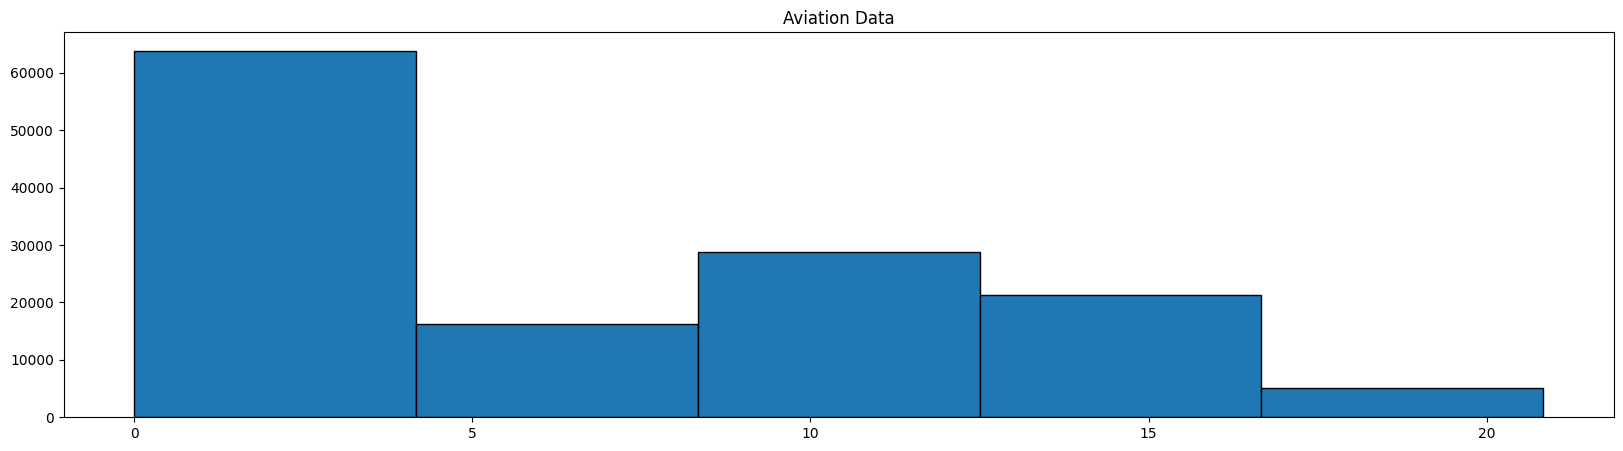

In [249]:
plt.figure(figsize=(20,5))
plt.hist(aviation_data["emissions_quantity"],edgecolor="black",bins=5)
plt.title("Aviation Data")
plt.show()

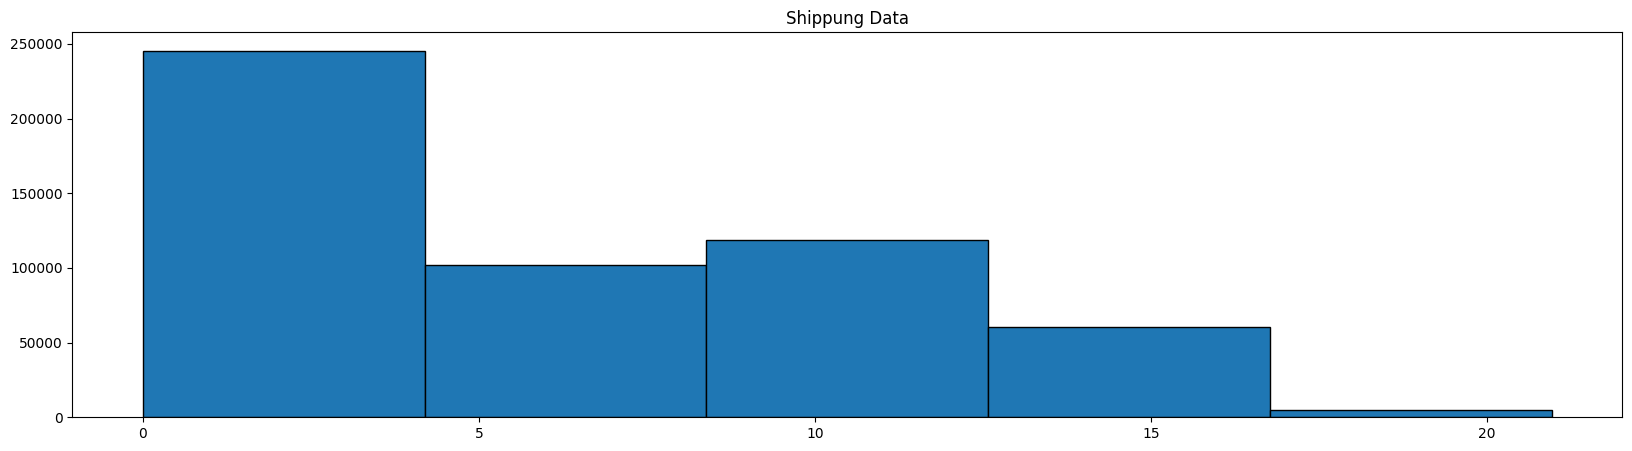

In [250]:
plt.figure(figsize=(20,5))
plt.hist(shipping_data["emissions_quantity"],edgecolor="black",bins=5)
plt.title("Shippung Data")
plt.show()

# 4. Data Visualization

As your aircraft data, as well as your shipping data are cleaned and prepared, you are asked to perform a comparison between both transports links. For this, pls plot both data in one figure.The visual insights will help communicate findings to management.
Your Tasks:

1. Create visualizations (histogram) to show:
    - make sure they are in one figure
    - add x- and y-label 
    - add title 
    - visualize them in a way that both data distributions can be clearly seen
    - add the respective label and assign different colors
2. Which transport links performs better in terms of emissions?
3. Plot the relation of emissions_quanitities and the respective capacity of the aircrafts/ships in a scatter plot- can you spot some clusters (also both datasets in one figure )- Tip: reverse your log-transformation first
4. Based on your scatter plot, do you identify clusters in the vessel fleet?


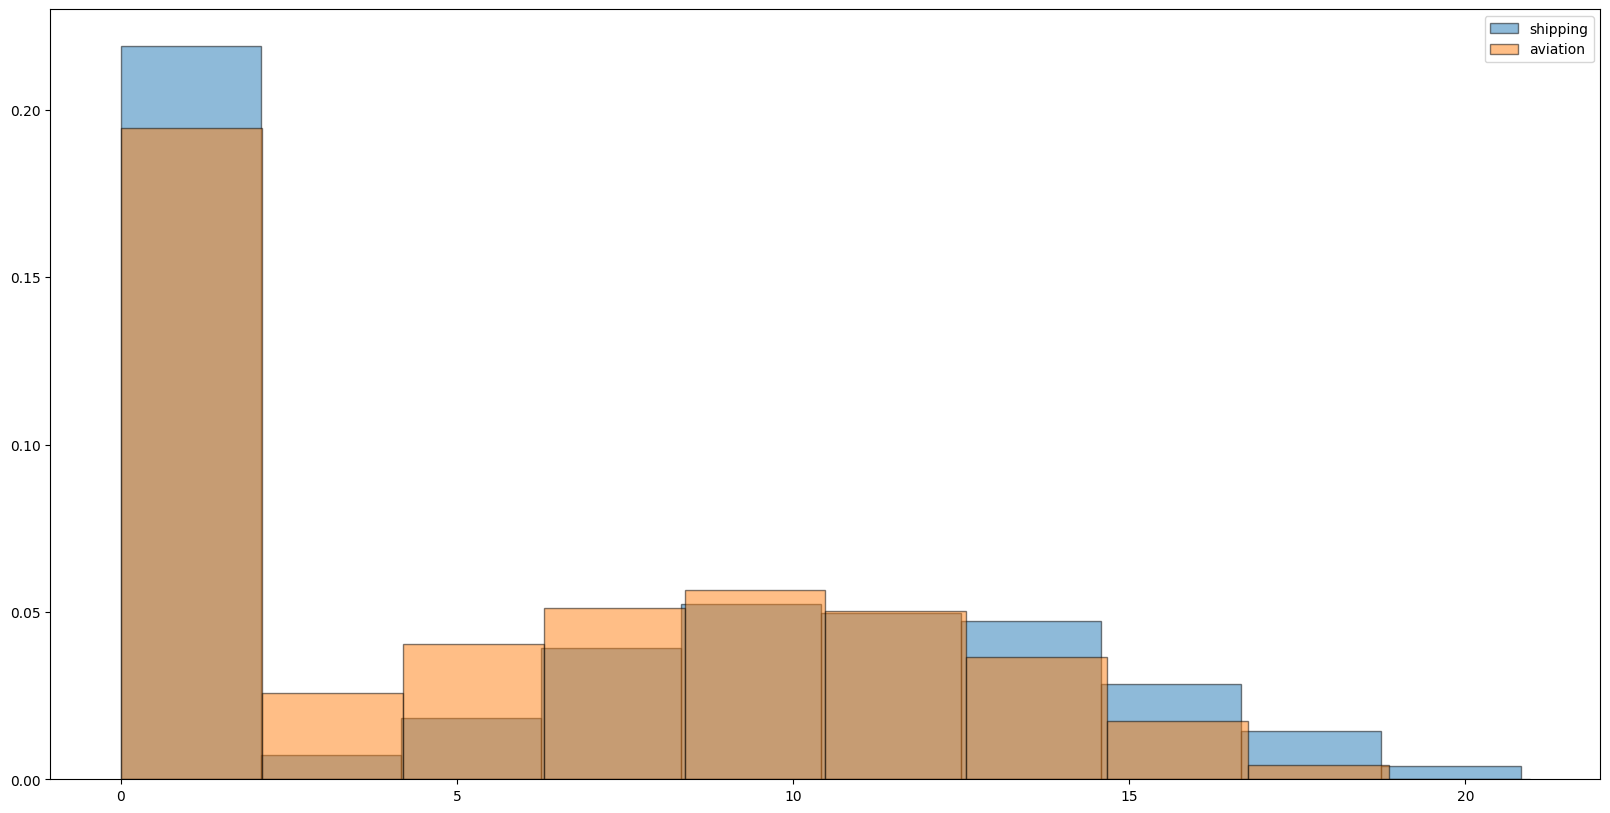

In [251]:
# Histogram

labels=["shipping","aviation"]

plt.figure(figsize=(20,10))
for data,label in zip(csv_list,labels):
    x=data["emissions_quantity"]
    plt.hist(x,edgecolor="black",density=True,alpha=0.5,label=label)
plt.legend()
plt.show()

In [252]:
def reverse(data):
    data["emissions_quantity"]=np.exp(data["emissions_quantity"])
    return data
for data in csv_list:
    reverse(data)

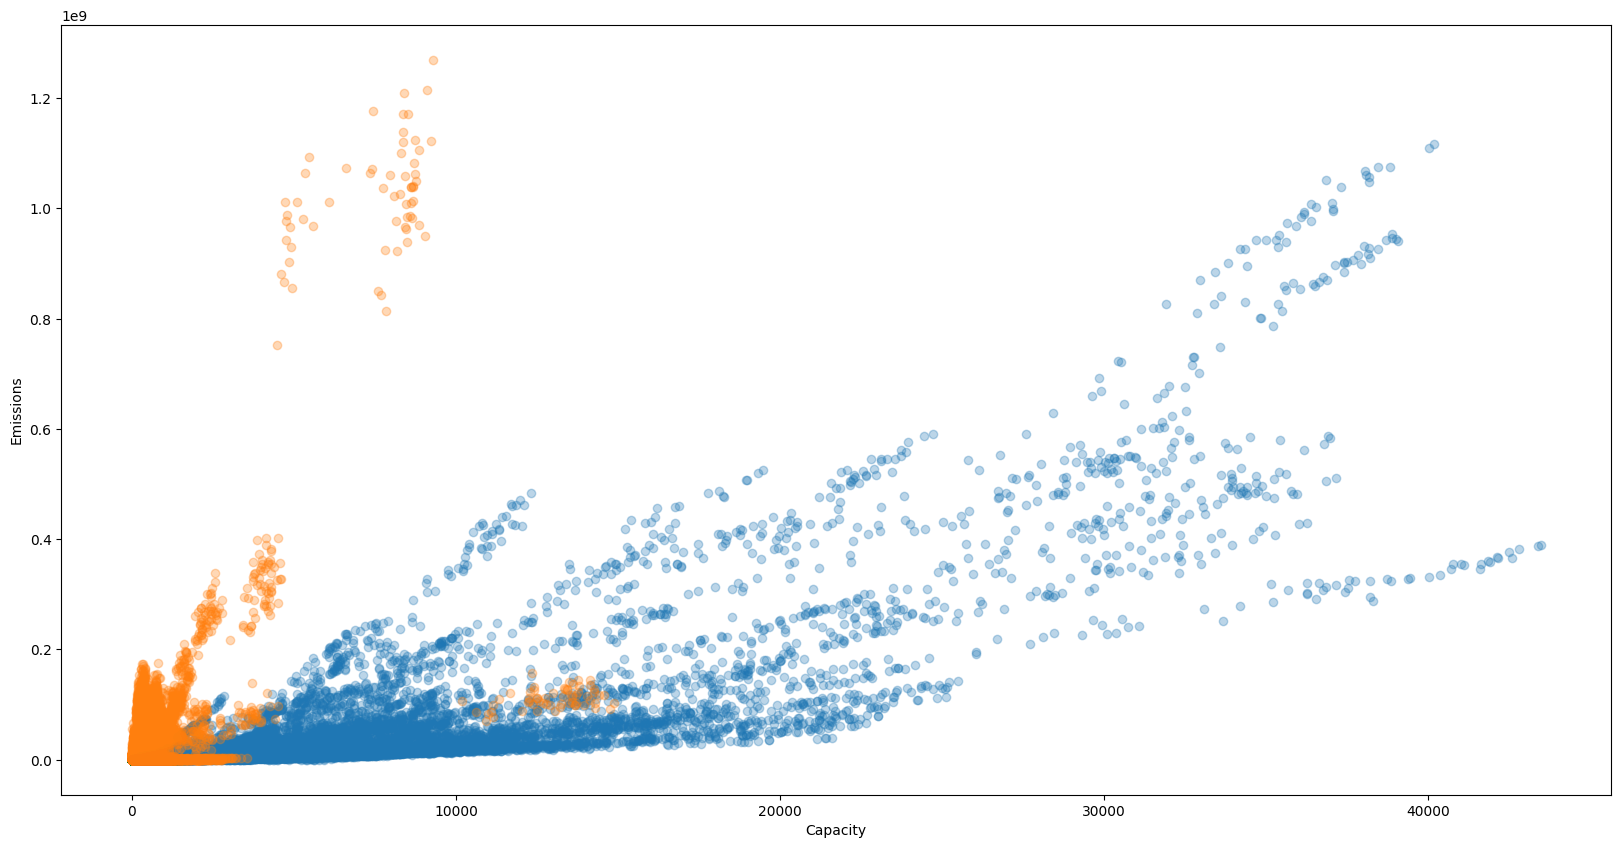

In [253]:
#scatter plot
plt.figure(figsize=(20,10))
for data, label in zip(csv_list,labels):
    x=data["capacity"]
    y=data["emissions_quantity"]
    plt.scatter(x,y,label=label,alpha=0.3)
    plt.xlabel("Capacity")
    plt.ylabel("Emissions")


# 5. Advanced Analytics and Predictive Modeling 

EcoTrans' head of logisitcs was amazed by your work and the visualization. He is concerned that there might by a real issue with old aircrafts/ships and their respective emissions. He is asking you whether you can calcualte the effect of capacity on the respective emission. 
Your tasks:

1. Train a linear regression model on both datasets each and report the beta-coefficient, as well as the R_sqaured


In [254]:
# train a linear Regression model for the aircraft data
x=aviation_data[["capacity"]]
y=aviation_data["emissions_quantity"]
Linear_Aircraft=LinearRegression()
Linear_Aircraft.fit(x,y)
beta_coeffcient=Linear_Aircraft.coef_
print(f"The beta coefficient is about {np.round(Linear_Aircraft.coef_,2)}")
print(f"The score/R_squared is about {np.round(Linear_Aircraft.score(x,y),2)}%")





The beta coefficient is about [10636.22]
The score/R_squared is about 0.63%


In [255]:
# train a linear Regression model for the shipping data
x=shipping_data[["capacity"]]
y=shipping_data["emissions_quantity"]
Linear_Ships=LinearRegression()
Linear_Ships.fit(x,y)
beta_coeffcient=Linear_Ships.coef_
print(f"The beta coefficient is about {np.round(Linear_Ships.coef_,2)}")
print(f"The score/R_squared is about {np.round(Linear_Ships.score(x,y),2)}%")


The beta coefficient is about [36504.39]
The score/R_squared is about 0.33%


Can you spot the difference it their scores? Why is the linear model for the shipping data performing that bad? 


The next plot is just for you, to see that a straight line from first degree polynomial model is not appropriate

<Axes: xlabel='capacity', ylabel='emissions_quantity'>

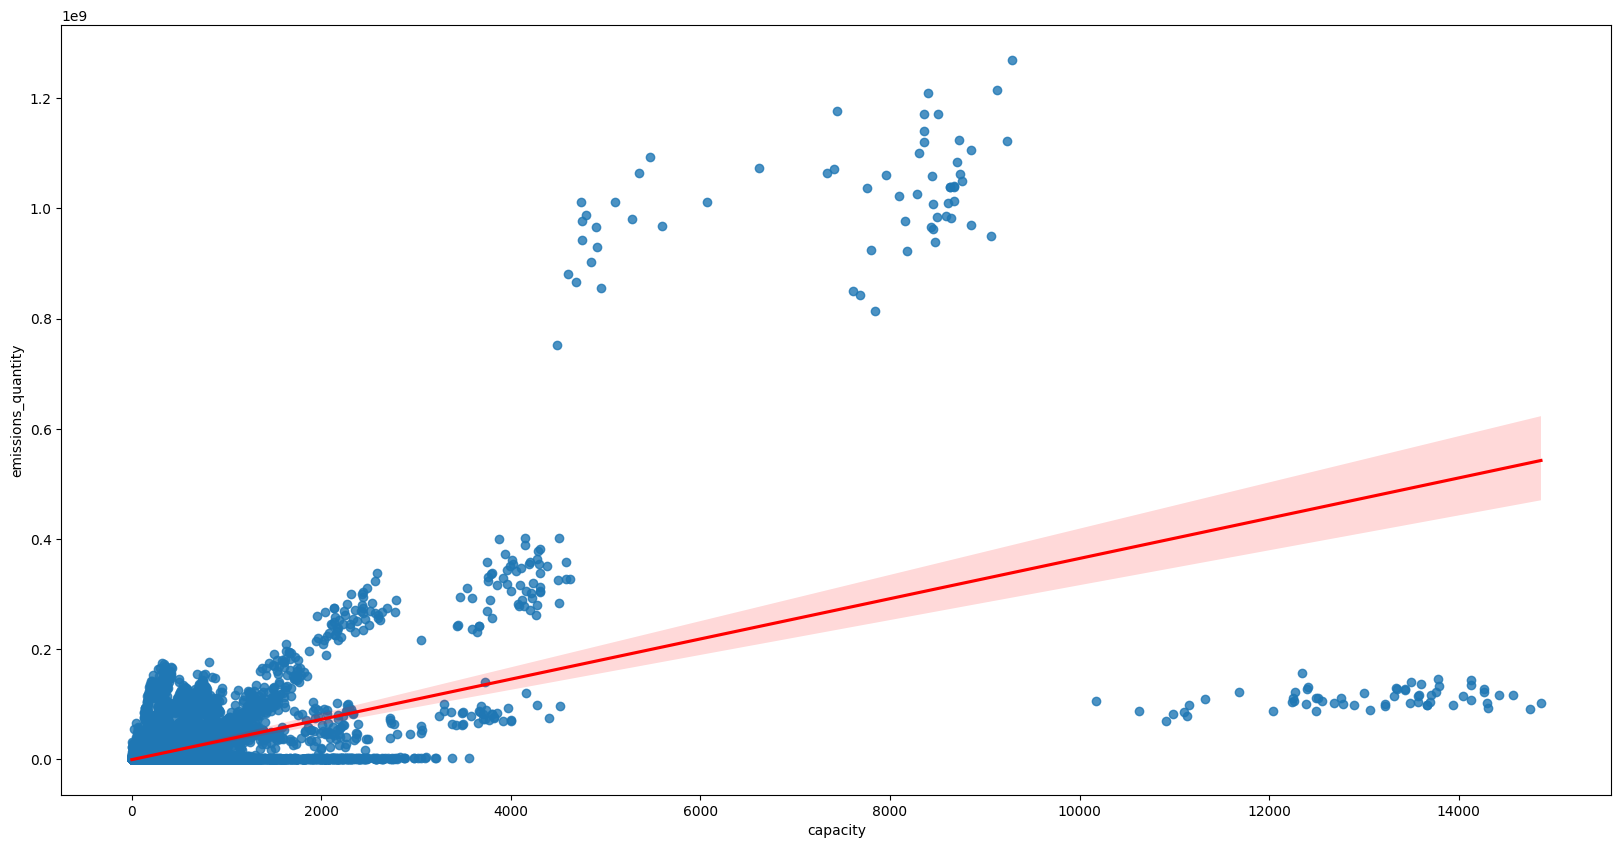

In [256]:
import seaborn as sns
plt.figure(figsize=(20,10))
sns.regplot(data=shipping_data,x=shipping_data["capacity"],y=shipping_data["emissions_quantity"],line_kws={"color":"red"})

You ask your collegue and he is advising you to try out a polynomial regression. The advantage is that you add some degree of freedom and you might end up with a better score. 

Your task:
1. Build up a polynomial Regression model just for the shipping data with polynomial degree of 3
2. Report the new score, did it improve?
3. Try to visualize the new regression line 


In [257]:
# polynomial regression model/
poly=3
poly_transfer=PolynomialFeatures(poly)
x_poly=poly_transfer.fit_transform(x)

Poly_Model=LinearRegression()
Poly_Model.fit(x_poly,y)
R_squared=Poly_Model.score(x_poly,y)

print(f"The new score is now {np.round(R_squared,2)}")


The new score is now 0.62


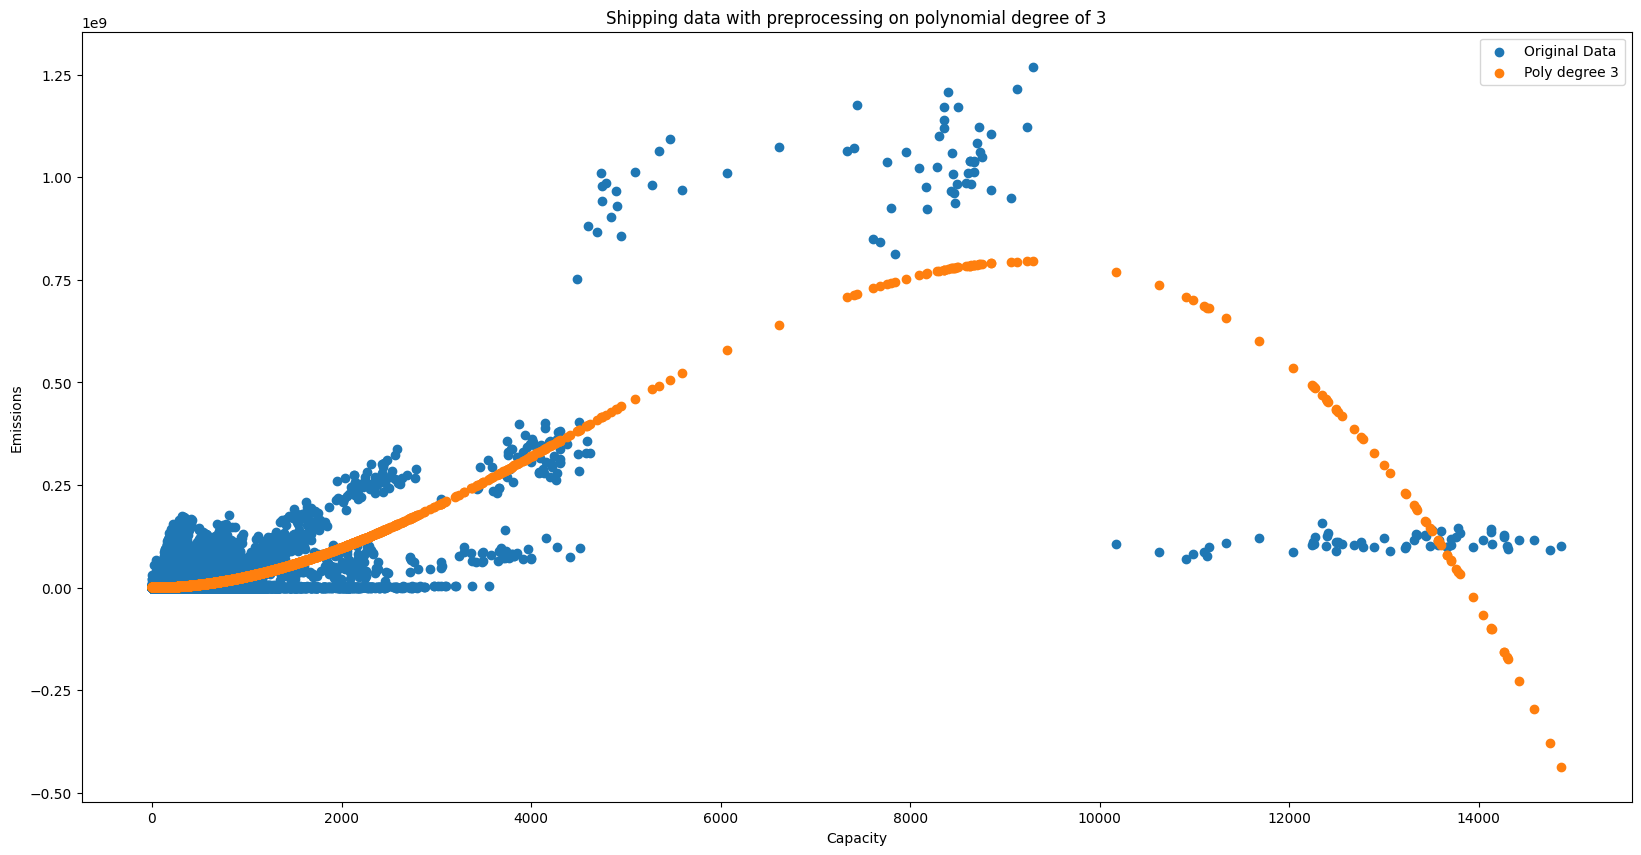

In [258]:
# Visualization 
plt.figure(figsize=(20,10))
y_predict=Poly_Model.predict(x_poly)
plt.scatter(x,y,label="Original Data")
plt.scatter(x,y_predict,label="Poly degree 3")
plt.xlabel("Capacity")
plt.ylabel("Emissions")
plt.legend()
plt.title("Shipping data with preprocessing on polynomial degree of 3")
plt.show()


It looks a bit better but acutally not perfect at all. But you might something else? Remeber, we want to find cluster/patterns. Maybe you see patterns of ships which are not efficient enough? 

As we not just visually identify patterns but also confirm by analytical methods, we implemenet a Kmeans cluster algorithm. But before it is useful to scale the values as we have huge emission values and small capacity values and the Kmeans is distance based. 

In [259]:
# some preprocessing 

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
data=shipping_data[["capacity","emissions_quantity"]]
scaler=StandardScaler()
data_scaled=scaler.fit_transform(data)

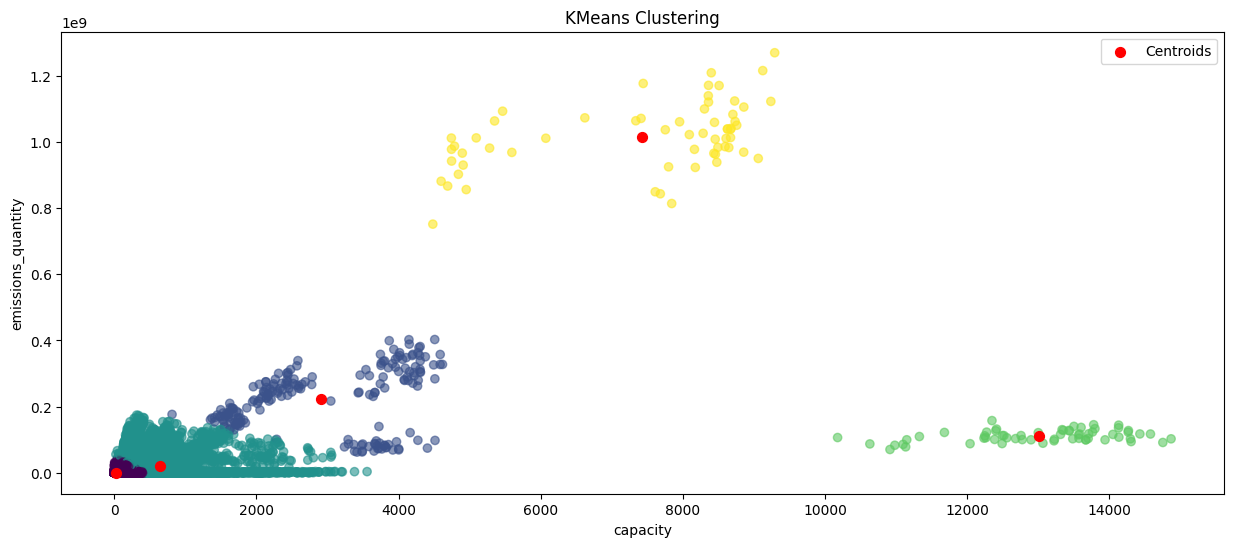

In [260]:
data = shipping_data[["capacity", "emissions_quantity"]]

# Skalieren
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# KMeans
kmeans = KMeans(n_clusters=5, n_init="auto")
labels = kmeans.fit_predict(data_scaled)
# Zentren zurücktransformieren
centers = scaler.inverse_transform(kmeans.cluster_centers_)

# Plot
plt.figure(figsize=(15,6))
plt.scatter(
    data["capacity"],
    data["emissions_quantity"],
    c=labels,
    cmap="viridis",
    alpha=0.6
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    color="red",
    s=200,
    marker=".",
    label="Centroids"
)

plt.xlabel("capacity")
plt.ylabel("emissions_quantity")
plt.legend()
plt.title("KMeans Clustering")

plt.show()



The k-cluster algorithm is an algorithm which requests deterministic specification of the amount of the clusters centers. But how to know how many clusters center to select?

Rule of thump: Elbow-Rule


Your Task:
- Report the scores of your trained model 
- Plot them on a line plot 
- how many clusters you would select?
- based on the clusters, which ship type you would recommend to retire?

Text(0.5, 0, 'Cluster Centers')

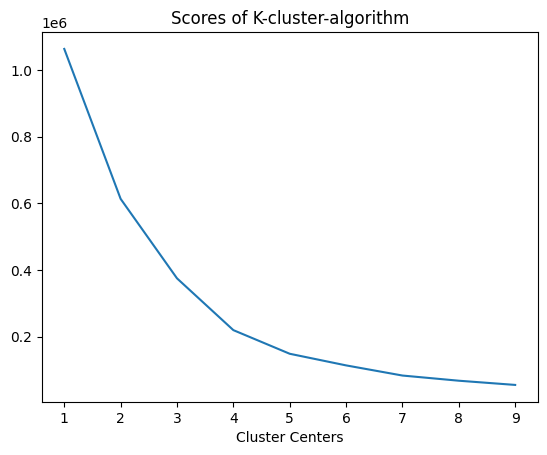

In [274]:
scores=[]
plt.figure(figsize=(20,10))
for k in range(1,10):
    kmeans = KMeans(n_clusters=k, n_init="auto").fit(data_scaled)

    score=np.abs(kmeans.score(data_scaled))
    scores.append(score)



plt.plot(np.arange(1,10,1),scores)
plt.title("Scores of K-cluster-algorithm")
plt.xlabel("Cluster Centers")






It seems to be appropriate to take 5 cluster centers. 

# 7. Sustainability Recommendations


Based on your analysis, provide actionable insights. You have identified that the ships associated with cluster 4 should be retired and leave the fleet. You are asked to provide csv data with the shipping data, extented by a label column, which included information about whether the ship is "ok", should be "retired" or is "super efficient". In our situation these categories are associated with the respective clusters. 

Your Tasks:

Recommend strategies to reduce emissions:
Fleet electrification?
Route optimization?
Identify quick wins vs. long-term investments.
Propose KPIs EcoTrans should track going forward.
Estimate potential impact:
% reduction in emissions
Cost savings

In [282]:
# extending the dataframe with the respective labels 
kmeans=KMeans(n_clusters=5,n_init="auto").fit(data_scaled)
shipping_data["labels"]=kmeans.predict(data_scaled)

labels
0    521472
3      9984
4       201
2        61
1        61
Name: count, dtype: int64

In [288]:
shipping_data["category"]="unknown"
shipping_data.loc[shipping_data["labels"]<=2,"category"]="ok"
shipping_data.loc[shipping_data["labels"]==3,"category"]="retire"
shipping_data.loc[shipping_data["labels"]>3,"category"]="super efficient"

shipping_data["category"].value_counts()

category
ok                 521594
retire               9984
super efficient       201
Name: count, dtype: int64

In [289]:
# Writing it into a csv 

shipping_report=shipping_data.to_csv("report.csv",sep=";")